In [1]:
# importing processed dataset for learning curves
import pandas as pd

path = '..\Dataset\simulation_matrix_updated_info.csv'

data = pd.read_csv(path)
data["Max_Equiv_Stress_Pa"] = data["Max_Equiv_Stress_Pa"].astype(str).str.replace(" ", "").astype(float)

FEATURE_COLS = ["Blade_Length_m", "Root_Chord_mm", "Material", "Applied_Load_Pa"]
X = data[FEATURE_COLS].copy()
y_stress = data["Max_Equiv_Stress_Pa"].copy()
y_deflection = data["Max_Deformation_m"].copy()

X_encoded = pd.get_dummies(X, columns=["Material"], prefix="Material")
NUMERIC_COLS = ["Blade_Length_m", "Root_Chord_mm", "Applied_Load_Pa"]

print(f"Loaded dataset: {data.shape[0]} rows, {data.shape[1]} columns")
print("Encoded features:", X_encoded.shape)

Loaded dataset: 81 rows, 8 columns
Encoded features: (81, 6)


In [2]:
# Importing important libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import learning_curve, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

print("All libraries loaded...")

All libraries loaded...


In [4]:
# Learning curve configuration - final model chosen -> XGBoost
preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), NUMERIC_COLS)],
    remainder="passthrough"
)

xgb_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
pipe = Pipeline([("prep", preprocessor), ("model", xgb_model)])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.2, 1.0, 8)

print("Learning curve configured (5-fold CV, 8 training-size steps)")

Learning curve configured (5-fold CV, 8 training-size steps)


# Stress Model

In [5]:
# Learning curve - Stress
sizes_s, train_scores_s, val_scores_s = learning_curve(
    pipe, X_encoded, y_stress, train_sizes=train_sizes, cv=kf, scoring="r2", shuffle=True, random_state=42
)

train_mean_s, train_std_s = train_scores_s.mean(axis=1), train_scores_s.std(axis=1)
val_mean_s, val_std_s = val_scores_s.mean(axis=1), val_scores_s.std(axis=1)

print("Training sizes:", sizes_s)
print("Train R2:", np.round(train_mean_s, 4))
print("Val R2:", np.round(val_mean_s, 4))

Training sizes: [12 20 27 34 42 49 56 64]
Train R2: [1.     0.9999 0.9999 0.9999 0.9999 1.     1.     1.    ]
Val R2: [-0.3264  0.105   0.7488  0.8987  0.9384  0.9826  0.9913  0.9992]


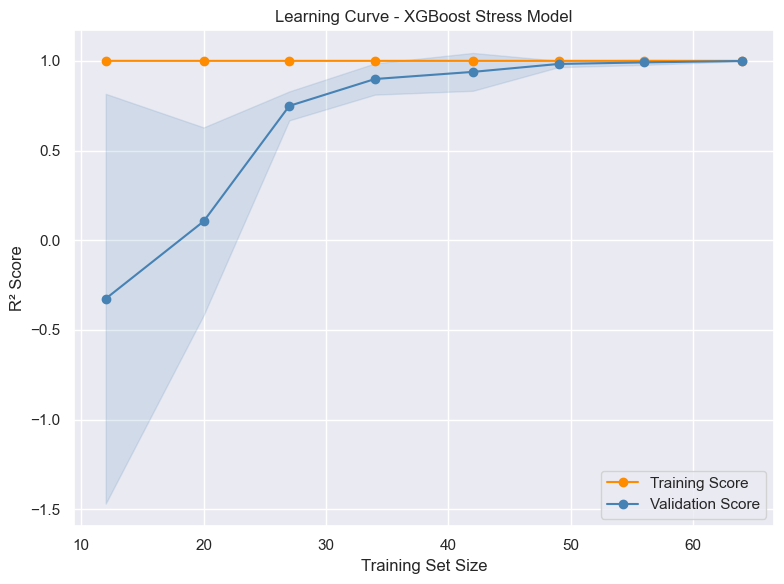

In [6]:
# Plot - Stress learning curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sizes_s, train_mean_s, "o-", color="darkorange", label="Training Score")
ax.fill_between(sizes_s, train_mean_s - train_std_s, train_mean_s + train_std_s, alpha=0.15, color="darkorange")
ax.plot(sizes_s, val_mean_s, "o-", color="steelblue", label="Validation Score")
ax.fill_between(sizes_s, val_mean_s - val_std_s, val_mean_s + val_std_s, alpha=0.15, color="steelblue")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("R² Score")
ax.set_title("Learning Curve - XGBoost Stress Model")
ax.legend()
plt.tight_layout()
plt.show()

# Deformation Model

In [7]:
# Learning curve - Deflection
sizes_d, train_scores_d, val_scores_d = learning_curve(
    pipe, X_encoded, y_deflection, train_sizes=train_sizes, cv=kf, scoring="r2", shuffle=True, random_state=42
)

train_mean_d, train_std_d = train_scores_d.mean(axis=1), train_scores_d.std(axis=1)
val_mean_d, val_std_d = val_scores_d.mean(axis=1), val_scores_d.std(axis=1)

print("Training sizes:", sizes_d)
print("Train R2:", np.round(train_mean_d, 4))
print("Val R2:", np.round(val_mean_d, 4))

Training sizes: [12 20 27 34 42 49 56 64]
Train R2: [0.9956 0.9987 0.999  0.9984 0.9986 0.9983 0.9982 0.9979]
Val R2: [-1.2542 -0.254  -0.2494  0.2649  0.4726  0.32    0.6089  0.5792]


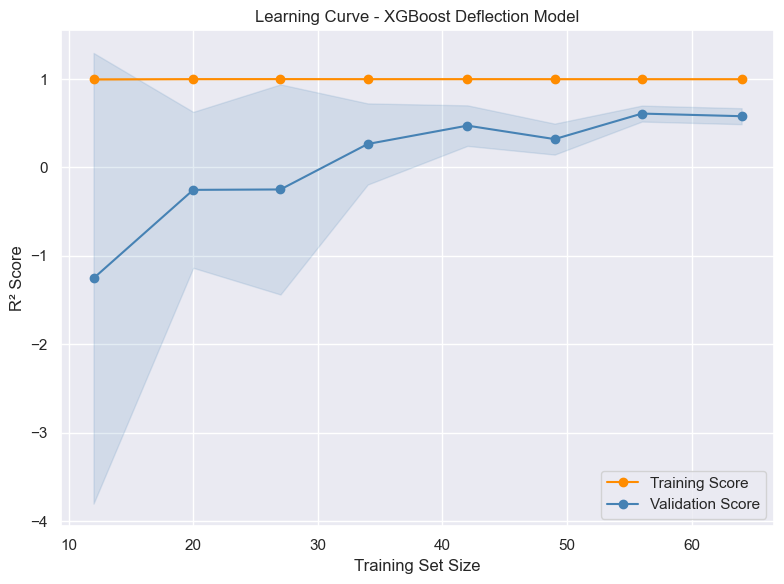

In [8]:
# Plot - Deflection learning curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sizes_d, train_mean_d, "o-", color="darkorange", label="Training Score")
ax.fill_between(sizes_d, train_mean_d - train_std_d, train_mean_d + train_std_d, alpha=0.15, color="darkorange")
ax.plot(sizes_d, val_mean_d, "o-", color="steelblue", label="Validation Score")
ax.fill_between(sizes_d, val_mean_d - val_std_d, val_mean_d + val_std_d, alpha=0.15, color="steelblue")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("R² Score")
ax.set_title("Learning Curve - XGBoost Deflection Model")
ax.legend()
plt.tight_layout()
plt.show()

# Diagnosis

In [9]:
# Model diagnosis table
def diagnose(train_score, val_score, gap_threshold=0.15):
    gap = train_score - val_score
    if gap > gap_threshold:
        return "Overfitting"
    elif train_score < 0.85 and val_score < 0.85:
        return "Underfitting"
    else:
        return "Well-fitted"

diagnosis_df = pd.DataFrame([
    {"Model": "Stress", "Training Score": train_mean_s[-1], "Validation Score": val_mean_s[-1],
     "Diagnosis": diagnose(train_mean_s[-1], val_mean_s[-1])},
    {"Model": "Deflection", "Training Score": train_mean_d[-1], "Validation Score": val_mean_d[-1],
     "Diagnosis": diagnose(train_mean_d[-1], val_mean_d[-1])},
])
diagnosis_df

,Model,Training Score,Validation Score,Diagnosis
0,Stress,0.999959,0.999198,Well-fitted
1,Deflection,0.997892,0.579234,Overfitting
